## Import libraries

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict,
    RepeatedStratifiedKFold
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier

## Load data

In [106]:
clinical_gex = pd.read_csv(
    '../dataset/created/clinical_gex/clinical_gex_w_target.csv',
    index_col='Unnamed: 0',
    low_memory=False
)
clinical_gex = clinical_gex[clinical_gex['source'].isin(['Yan et al.', 'Kwong et al.'])]

y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'BOR'], axis=1)

# Encode drug and BRAF_mut as dummies (these are fixed per sample, not learned)
drug_dummies = x['drug'].str.get_dummies(sep='+')
x = pd.concat([x.drop('drug', axis=1), drug_dummies], axis=1)
braf_mut_dummies = x['BRAF_mut'].str.get_dummies(sep=';')
x = pd.concat([x.drop('BRAF_mut', axis=1), braf_mut_dummies], axis=1)

print(x.head())
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

      sex  age AJCC_stage M_stage       LDH brain_metastasis  \
0    male   26         IV     M1B  elevated              NaN   
1  female   58         IV     M1A    normal              NaN   
2    male   45         IV     M1A    normal              NaN   
3    male   48       IIIC     NaN    normal              NaN   
4    male   33         IV     M1C    normal              NaN   

  immunotherapy_treatment pre_MAPKi_treatment   Method     CEBPZ  ...  \
0                      no                  no  RNA-seq  6.955717  ...   
1                      no                  no  RNA-seq  6.903313  ...   
2                      no                  no  RNA-seq  7.303079  ...   
3                      no                  no  RNA-seq  6.563531  ...   
4                      no                  no  RNA-seq  6.741286  ...   

      HAUS6  MIRLET7D   cobimetinib   trametinib  dabrafenib   vemurafenib  \
0  4.463209  4.004989             0            0            0            1   
1  4.603643  4.32463

In [107]:
# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH', 'brain_metastasis',
    'immunotherapy_treatment', 'pre_MAPKi_treatment', 'Method'
]
clinical_numeric_col = ['age']

# Drug/BRAF dummies (already binary, passthrough)
drug_braf_cols = list(drug_dummies.columns) + list(braf_mut_dummies.columns)

# Gene expression columns (everything else)
all_non_gex = (
    clinical_ordinal_col + clinical_categorical_cols +
    clinical_numeric_col + drug_braf_cols
)
gex_cols = [c for c in x.columns if c not in all_non_gex]

print(f"\nClinical features: {len(clinical_ordinal_col) + len(clinical_categorical_cols) + len(clinical_numeric_col)}")
print(f"Drug/BRAF dummies: {len(drug_braf_cols)}")
print(f"Gene expression features: {len(gex_cols)}")


Clinical features: 9
Drug/BRAF dummies: 8
Gene expression features: 13192


## Load KEGG + VCELLS genes

In [108]:
with open('../dataset/combine-kegg-vcells.txt', 'r') as f:
    content = f.read().replace('\n', ' ')
    kegg_vcells_genes = set(gene.strip() for gene in content.split(',') if gene.strip())

gex_gene_names = set(gex_cols)
kegg_vcells_overlap = sorted(kegg_vcells_genes.intersection(gex_gene_names))
remainder_genes = sorted([g for g in gex_cols if g not in kegg_vcells_overlap])

print(f"\nKEGG+VCELLS genes in dataset: {len(kegg_vcells_overlap)}")
print(f"Remaining genes: {len(remainder_genes)}")


KEGG+VCELLS genes in dataset: 158
Remaining genes: 13034


## Pipeline

In [109]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV, VarianceThreshold

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),

        ('drug_braf', 'passthrough', drug_braf_cols),
        ('kegg_vcells', 'passthrough', kegg_vcells_overlap),
        
        ('remainder_gex', Pipeline([
            # ('var_thes', VarianceThreshold(threshold=0.9)),
            ('selectkbest', SelectKBest(f_classif, k=500)),
            ('pca', PCA(n_components=0.9)),
        ]), remainder_genes)
    ],
    remainder='drop'
)

feature_select_pipe = Pipeline([
    ('feature_select', Pipeline([
        ('preprocess', clinical_preprocessor),
        ('rfe', RFECV(
            estimator=RandomForestClassifier(random_state=42),
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            n_jobs=-1,
            step=1
            ))
        ]))])

pipe = Pipeline([
    ('feature_select', Pipeline([
        ('preprocess', clinical_preprocessor),
        ('rfe', RFE(
            estimator=RandomForestClassifier(random_state=42),
            n_features_to_select=20,
            step=1
            ))
        ])),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        eval_metric='mlogloss',
        random_state=42
    ))
])

## Cross-validation

In [110]:
INCLUDE_TEST_FOR_FEATURE_SELECT = False

In [111]:
if INCLUDE_TEST_FOR_FEATURE_SELECT == True: 
    x_rfe = feature_select_pipe.fit_transform(x, y)

    support = feature_select_pipe.named_steps['feature_select'].named_steps['rfe'].support_
    feature_names = feature_select_pipe.named_steps['feature_select'].named_steps['preprocess'].get_feature_names_out()
    selected_features = feature_names[support]

    x = pd.DataFrame(x_rfe, columns=selected_features, index=x.index)
    x

Test ROC-AUC (OVO) : 0.476 ± 0.054
Test Macro F1      : 0.288 ± 0.033
Train ROC-AUC (OVO): 1.000 ± 0.000
Train Macro F1     : 1.000 ± 0.000


              precision    recall  f1-score   support

  Short resp       0.50      0.58      0.54        43
Intermediate       0.00      0.00      0.00        10
   Long resp       0.33      0.34      0.34        29

    accuracy                           0.43        82
   macro avg       0.28      0.31      0.29        82
weighted avg       0.38      0.43      0.40        82



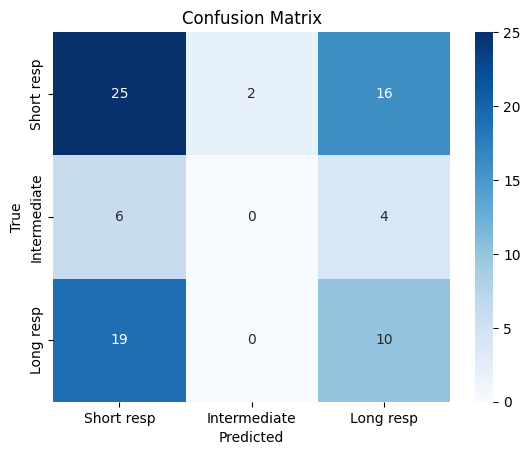

In [112]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_clf = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=1.0,
            reg_lambda=1.0,
            eval_metric='mlogloss',
            random_state=42
        )

if INCLUDE_TEST_FOR_FEATURE_SELECT == True:
    results = cross_validate(
        xgb_clf, x, y,
        cv=cv,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        # params={'clf__sample_weight': sample_weights},
        n_jobs=-1
    )
    y_pred = cross_val_predict(xgb_clf, x, y, cv=cv, n_jobs=-1)

    
else: 
    results = cross_validate(
        pipe, x, y,
        cv=cv,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        # params={'clf__sample_weight': sample_weights},
        n_jobs=-1
    )
    y_pred = cross_val_predict(pipe, x, y, cv=cv, n_jobs=-1)


print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")

print("\n")
print(classification_report(
    y, y_pred,
    target_names=['Short resp', 'Intermediate', 'Long resp']
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Short resp','Intermediate','Long resp'],
            yticklabels=['Short resp','Intermediate','Long resp'],
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()